In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Bidirectional
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
df = pd.read_csv("/content/Job_3_Resource_sentiment.csv")
print(df.columns)

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')


In [8]:
df.sample(5)

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
11531,13182,Xbox(Xseries),Irrelevant,I loved the clip but that is not what I call “...
22431,4240,CS-GO,Irrelevant,dota 2 is almost objectively the worst valve g...
16333,3196,Dota2,Neutral,@ dota2updates this was fun when I had 100 but...
14859,2945,Dota2,Negative,@DOTA2 i said it just once I'll probably say i...
53846,2052,CallOfDuty,Irrelevant,You ur all doing truly wonderful service to th...


In [9]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [10]:
df.rename(columns={'Positive': 'sentiment'}, inplace=True)
df.rename(columns={'im getting on borderlands and i will murder you all ,': 'text'}, inplace=True)

In [11]:
df.columns

Index(['2401', 'Borderlands', 'sentiment', 'text'], dtype='object')

In [12]:
df = df[['text', 'sentiment']]

In [13]:
df.sample(5)

,text,sentiment
7785,Me and @KremeKrispie from arguing with people ...,Irrelevant
22744,Received fantastic great honor a. Got best of ...,Positive
5400,@ amazon @ amazonIN @ AmazonHelp I pre-booked ...,Negative
46770,Thank you to @ Target and @ HomeDepot for keep...,Positive
21480,"t use OBS, NVIDIA Shadow Play, even Discord? T...",Negative


In [14]:
df.shape

(74681, 2)

In [15]:
df.isnull().sum()

,0
text,686
sentiment,0


In [16]:
print(df['sentiment'].value_counts())

sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [17]:
#step 10
# Drop missing values
df.dropna(inplace=True)

/tmp/ipykernel_3249/3754071041.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [18]:
df.isnull().sum()

,0
text,0
sentiment,0


In [19]:
# Convert text to string
df['text'] = df['text'].astype(str)

/tmp/ipykernel_3249/3792616058.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].astype(str)


In [20]:
df['text']

,text
0,I am coming to the borders and I will kill you...
1,im getting on borderlands and i will kill you ...
2,im coming on borderlands and i will murder you...
3,im getting on borderlands 2 and i will murder ...
4,im getting into borderlands and i can murder y...
...,...
74676,Just realized that the Windows partition of my...
74677,Just realized that my Mac window partition is ...
74678,Just realized the windows partition of my Mac ...
74679,Just realized between the windows partition of...


In [21]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

/tmp/ipykernel_3249/1069262265.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].apply(clean_text)


In [22]:
df['text']

,text
0,i am coming to the borders and i will kill you...
1,im getting on borderlands and i will kill you all
2,im coming on borderlands and i will murder you...
3,im getting on borderlands and i will murder y...
4,im getting into borderlands and i can murder y...
...,...
74676,just realized that the windows partition of my...
74677,just realized that my mac window partition is ...
74678,just realized the windows partition of my mac ...
74679,just realized between the windows partition of...


In [23]:
#step 11
encoder = LabelEncoder()
df['sentiment_encoded'] = encoder.fit_transform(df['sentiment'])

print("Label mapping:")
for i, c in enumerate(encoder.classes_):
    print(i, "->", c)

Label mapping:
0 -> Irrelevant
1 -> Negative
2 -> Neutral
3 -> Positive


/tmp/ipykernel_3249/2691065891.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment_encoded'] = encoder.fit_transform(df['sentiment'])


In [24]:
max_words = 20000
max_length = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

X = pad_sequences(
    tokenizer.texts_to_sequences(df['text']),
    maxlen=max_length,
    padding='post'
)

y = df['sentiment_encoded'].values

In [25]:
y

array([3, 3, 3, ..., 3, 3, 3])

In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (51796, 100)
Validation: (11099, 100)
Test: (11100, 100)


In [27]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)


Class Weights: {0: np.float64(1.4368619618286729), 1: np.float64(0.8274121405750798), 2: np.float64(1.0215367623856106), 3: np.float64(0.8956287176649605)}


In [28]:
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(max_words, 128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,332 (10.14 MB)

 Trainable params: 2,659,332 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
early = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early],
    class_weight=class_weights_dict
)

Epoch 1/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.6393 - loss: 0.9082 - val_accuracy: 0.7600 - val_loss: 0.6309
Epoch 2/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.8307 - loss: 0.4673 - val_accuracy: 0.8234 - val_loss: 0.4918
Epoch 3/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.8843 - loss: 0.3159 - val_accuracy: 0.8464 - val_loss: 0.4237
Epoch 4/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9091 - loss: 0.2450 - val_accuracy: 0.8505 - val_loss: 0.4412
Epoch 5/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9231 - loss: 0.2042 - val_accuracy: 0.8559 - val_loss: 0.4474
Epoch 6/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9340 - loss: 0.1743 - val_accuracy: 0.8628 - val_loss: 0.4514


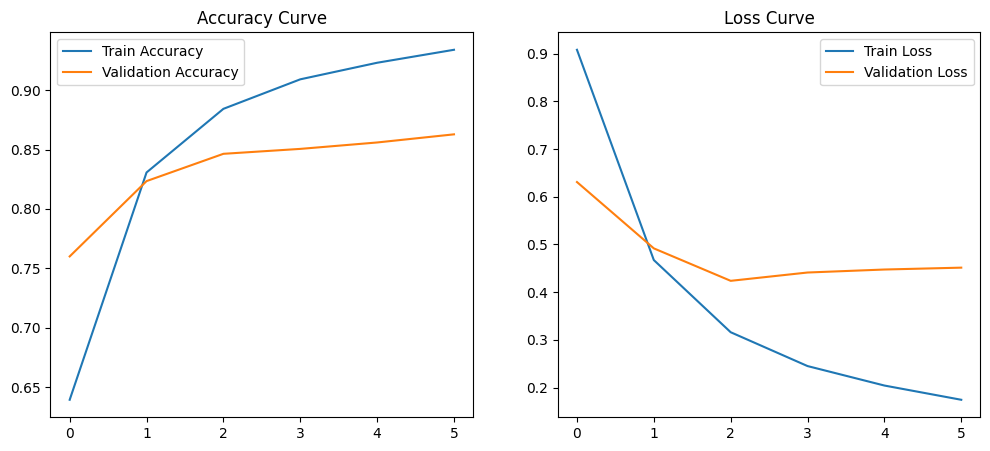

In [31]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [32]:
if history.history['accuracy'][-1] > history.history['val_accuracy'][-1]:
    print("Possible Overfitting detected")
else:
    print("Model is generalizing well")

Possible Overfitting detected


In [33]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

347/347 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Accuracy: 0.848018018018018
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1932
           1       0.88      0.87      0.87      3354
           2       0.85      0.82      0.84      2716
           3       0.83      0.86      0.85      3098

    accuracy                           0.85     11100
   macro avg       0.85      0.85      0.84     11100
weighted avg       0.85      0.85      0.85     11100



In [34]:
model.save("sentiment_analysis_model.keras")
print("Model saved successfully")

Model saved successfully


In [35]:
def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=100, padding='post')
    probs = model.predict(pad)[0]
    return encoder.classes_[probs.argmax()], probs

texts = [
    "I love this game so much",
    "This game is terrible",
    "I have no opinion",
    "What is this even about?"
]

for t in texts:
    pred, prob = predict_sentiment(t)
    print(t, "->", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
I love this game so much -> Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
This game is terrible -> Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
I have no opinion -> Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
What is this even about? -> Negative
